# 01 - Exploratory Data Analysis

**Project:** Predictive Maintenance - Maintenance Required Prediction
**Dataset:** Logistics Vehicle Maintenance History (Kaggle, CC0, 92 000 rows)
**Goal:** Understand the data structure, assess quality, explore feature distributions,
identify relationships with the target variable, detect data leakage, and summarize
key findings before any modeling work.

---

## 1. Setup

In [1]:
# Import all required libraries for data analysis and visualization.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.3f}".format)

plt.rcParams["figure.dpi"] = 120
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.0)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
# Load the main dataset and confirm its shape.
DATA_PATH = "../data/raw/logistics_dataset_with_maintenance_required.csv"
df = pd.read_csv(DATA_PATH)
print(f"Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}")

Rows: 92,000  |  Columns: 27


## 2. Dataset Overview

In [3]:
# Display the first five rows to verify column names and sample values.
df.head()

,Vehicle_ID,Make_and_Model,Year_of_Manufacture,Vehicle_Type,Usage_Hours,Route_Info,Load_Capacity,Actual_Load,Last_Maintenance_Date,Maintenance_Type,Maintenance_Cost,Engine_Temperature,Tire_Pressure,Fuel_Consumption,Battery_Status,Vibration_Levels,Oil_Quality,Brake_Condition,Failure_History,Anomalies_Detected,Predictive_Score,Maintenance_Required,Weather_Conditions,Road_Conditions,Delivery_Times,Downtime_Maintenance,Impact_on_Efficiency
0,1,Ford F-150,2022,Truck,530,Rural,7.535,9.004,2023-04-09,Oil Change,110.165,120.000,20.000,5.000,45.000,2.247,80.394,Good,1,0,0.172,1,Clear,Highway,30.000,0.094,0.150
1,2,Volvo FH,2015,Van,10679,Rural,7.672,6.112,2023-07-20,Tire Rotation,265.898,120.000,20.000,5.000,45.000,0.851,91.302,Fair,1,0,0.247,1,Clear,Rural,30.000,3.361,0.343
2,3,Chevy Silverado,2022,Van,4181,Rural,2.901,3.006,2023-03-17,Oil Change,412.483,120.000,55.000,13.007,50.000,4.985,70.109,Good,1,1,0.455,1,Clear,Highway,48.628,1.365,0.100
3,4,Chevy Silverado,2011,Truck,2974,Urban,15.893,18.825,2024-05-01,Tire Rotation,444.111,120.000,20.000,5.000,45.000,3.000,74.932,Good,0,1,0.060,1,Clear,Highway,30.000,0.000,0.136
4,5,Ford F-150,2014,Van,2539,Rural,60.668,65.605,2023-11-15,Tire Rotation,478.842,120.000,55.000,5.000,50.000,3.942,86.357,Good,1,1,0.265,1,Rainy,Urban,300.000,6.609,0.395


In [4]:
# Show data types and non-null counts for every column.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 92000 entries, 0 to 91999
Data columns (total 27 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Vehicle_ID             92000 non-null  int64  
 1   Make_and_Model         92000 non-null  str    
 2   Year_of_Manufacture    92000 non-null  int64  
 3   Vehicle_Type           92000 non-null  str    
 4   Usage_Hours            92000 non-null  int64  
 5   Route_Info             92000 non-null  str    
 6   Load_Capacity          92000 non-null  float64
 7   Actual_Load            92000 non-null  float64
 8   Last_Maintenance_Date  92000 non-null  str    
 9   Maintenance_Type       92000 non-null  str    
 10  Maintenance_Cost       92000 non-null  float64
 11  Engine_Temperature     92000 non-null  float64
 12  Tire_Pressure          92000 non-null  float64
 13  Fuel_Consumption       92000 non-null  float64
 14  Battery_Status         92000 non-null  float64
 15  Vibration_Lev

In [5]:
# Compute descriptive statistics for all numerical columns.
df.describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
Vehicle_ID,92000.000,46000.500,26558.257,1.000,23000.750,46000.500,69000.250,92000.000
Year_of_Manufacture,92000.000,2016.968,5.360,2005.000,2013.000,2020.000,2021.000,2022.000
Usage_Hours,92000.000,2989.551,2992.083,0.000,856.000,2070.000,4146.000,36392.000
Load_Capacity,92000.000,25.068,25.040,0.000,7.233,17.402,34.746,332.342
Actual_Load,92000.000,23.771,24.195,0.000,6.726,16.245,32.682,264.034
Maintenance_Cost,92000.000,1043.005,1575.109,100.003,225.214,348.722,474.926,5999.905
Engine_Temperature,92000.000,120.000,0.000,120.000,120.000,120.000,120.000,120.000
Tire_Pressure,92000.000,32.571,14.483,20.000,20.000,24.517,48.811,55.000
Fuel_Consumption,92000.000,10.657,5.979,5.000,5.000,8.350,16.678,20.000
Battery_Status,92000.000,45.670,1.635,45.000,45.000,45.000,45.000,50.000


In [6]:
# Break down column types and list them by category.
num_cols  = df.select_dtypes(include="number").columns.tolist()
cat_cols  = df.select_dtypes(include=["object","string"]).columns.tolist()
print(f"Numerical  ({len(num_cols)}): {num_cols}")
print()
print(f"Categorical ({len(cat_cols)}): {cat_cols}")

Numerical  (19): ['Vehicle_ID', 'Year_of_Manufacture', 'Usage_Hours', 'Load_Capacity', 'Actual_Load', 'Maintenance_Cost', 'Engine_Temperature', 'Tire_Pressure', 'Fuel_Consumption', 'Battery_Status', 'Vibration_Levels', 'Oil_Quality', 'Failure_History', 'Anomalies_Detected', 'Predictive_Score', 'Maintenance_Required', 'Delivery_Times', 'Downtime_Maintenance', 'Impact_on_Efficiency']

Categorical (8): ['Make_and_Model', 'Vehicle_Type', 'Route_Info', 'Last_Maintenance_Date', 'Maintenance_Type', 'Brake_Condition', 'Weather_Conditions', 'Road_Conditions']


## 3. Data Quality Assessment

In [7]:
# Check every column for missing values.
missing = df.isna().sum()
if missing.sum() == 0:
    print("No missing values found in any column.")
else:
    print(missing[missing > 0])

No missing values found in any column.


In [8]:
# Check for fully duplicated rows.
dup = df.duplicated().sum()
print(f"Duplicate rows: {dup}" if dup > 0 else "No duplicate rows found.")

No duplicate rows found.


In [9]:
# Count unique values per column to detect constant or near-constant features.
unique_counts = df.nunique().sort_values()
print(unique_counts.to_string())

Engine_Temperature           1
Vehicle_Type                 2
Failure_History              2
Anomalies_Detected           2
Maintenance_Required         2
Brake_Condition              3
Maintenance_Type             3
Route_Info                   3
Road_Conditions              3
Make_and_Model               4
Weather_Conditions           4
Year_of_Manufacture         18
Last_Maintenance_Date      547
Battery_Status            4993
Usage_Hours              11975
Tire_Pressure            33079
Downtime_Maintenance     36761
Fuel_Consumption         43004
Delivery_Times           63595
Impact_on_Efficiency     71225
Oil_Quality              89907
Vehicle_ID               92000
Load_Capacity            92000
Actual_Load              92000
Vibration_Levels         92000
Maintenance_Cost         92000
Predictive_Score         92000


In [10]:
# Inspect Engine_Temperature and Battery_Status, which appear nearly constant.
print("Engine_Temperature unique values :", df["Engine_Temperature"].unique())
print()
print("Battery_Status value counts:")
print(df["Battery_Status"].value_counts())

Engine_Temperature unique values : [120.]

Battery_Status value counts:
Battery_Status
45.000    77055
50.000     9954
46.688        1
45.859        1
49.650        1
          ...  
49.676        1
46.223        1
46.678        1
47.199        1
48.922        1
Name: count, Length: 4993, dtype: int64


**Finding:** `Engine_Temperature` equals 120.0 for all 92 000 rows - it is a
constant and carries zero predictive value. `Battery_Status` has only 2 unique
values (45.0 and 50.0), which is suspiciously low for a sensor reading.
Both columns will be dropped during preprocessing.

## 4. Target Variable: Maintenance_Required

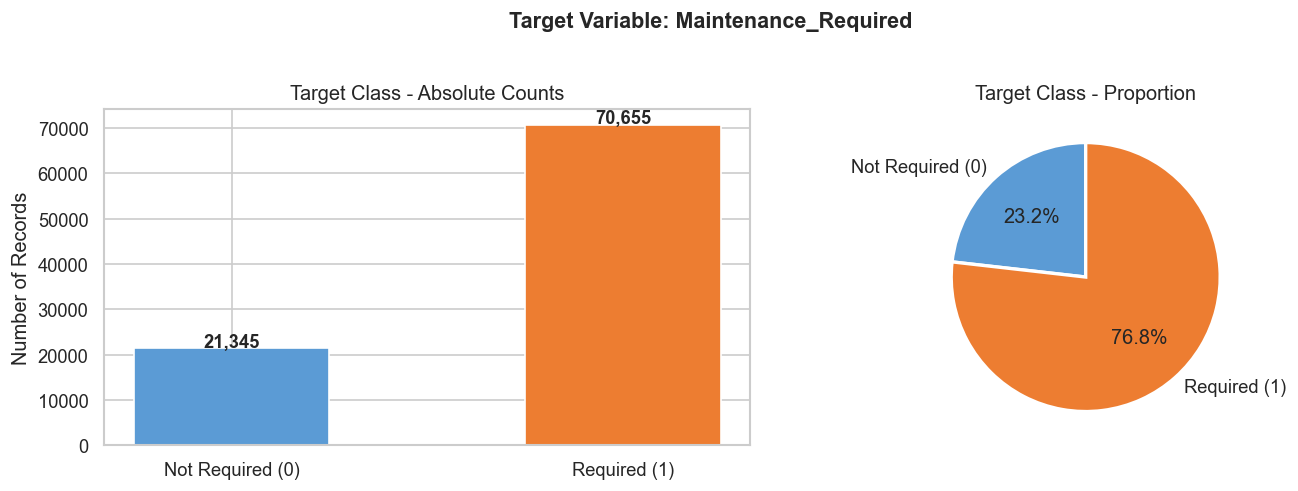

Class 0 (Not Required): 21,345  (23.2%)
Class 1 (Required):     70,655  (76.8%)
Imbalance ratio 1:0  =  3.31


In [11]:
# Visualize the class distribution of the binary target variable.
counts = df["Maintenance_Required"].value_counts().sort_index()
labels = ["Not Required (0)", "Required (1)"]
colors = ["#5B9BD5", "#ED7D31"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(labels, counts.values, color=colors, edgecolor="white", width=0.5)
axes[0].set_title("Target Class - Absolute Counts")
axes[0].set_ylabel("Number of Records")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 400, f"{v:,}", ha="center", fontweight="bold", fontsize=11)

axes[1].pie(counts.values, labels=labels, autopct="%1.1f%%",
            colors=colors, startangle=90,
            wedgeprops={"edgecolor": "white", "linewidth": 2})
axes[1].set_title("Target Class - Proportion")

plt.suptitle("Target Variable: Maintenance_Required", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../images/01_target_distribution.png", bbox_inches="tight")
plt.show()

print(f"Class 0 (Not Required): {counts[0]:,}  ({counts[0]/len(df)*100:.1f}%)")
print(f"Class 1 (Required):     {counts[1]:,}  ({counts[1]/len(df)*100:.1f}%)")
print(f"Imbalance ratio 1:0  =  {counts[1]/counts[0]:.2f}")

**Finding:** The dataset is moderately imbalanced - approximately 77 % of vehicles
require maintenance vs 23 % that do not. Accuracy alone will be misleading as a
metric. During modeling we will use F1-score, ROC-AUC, and Precision-Recall curves,
and apply class_weight='balanced' or resampling techniques.

## 5. Numerical Feature Distributions

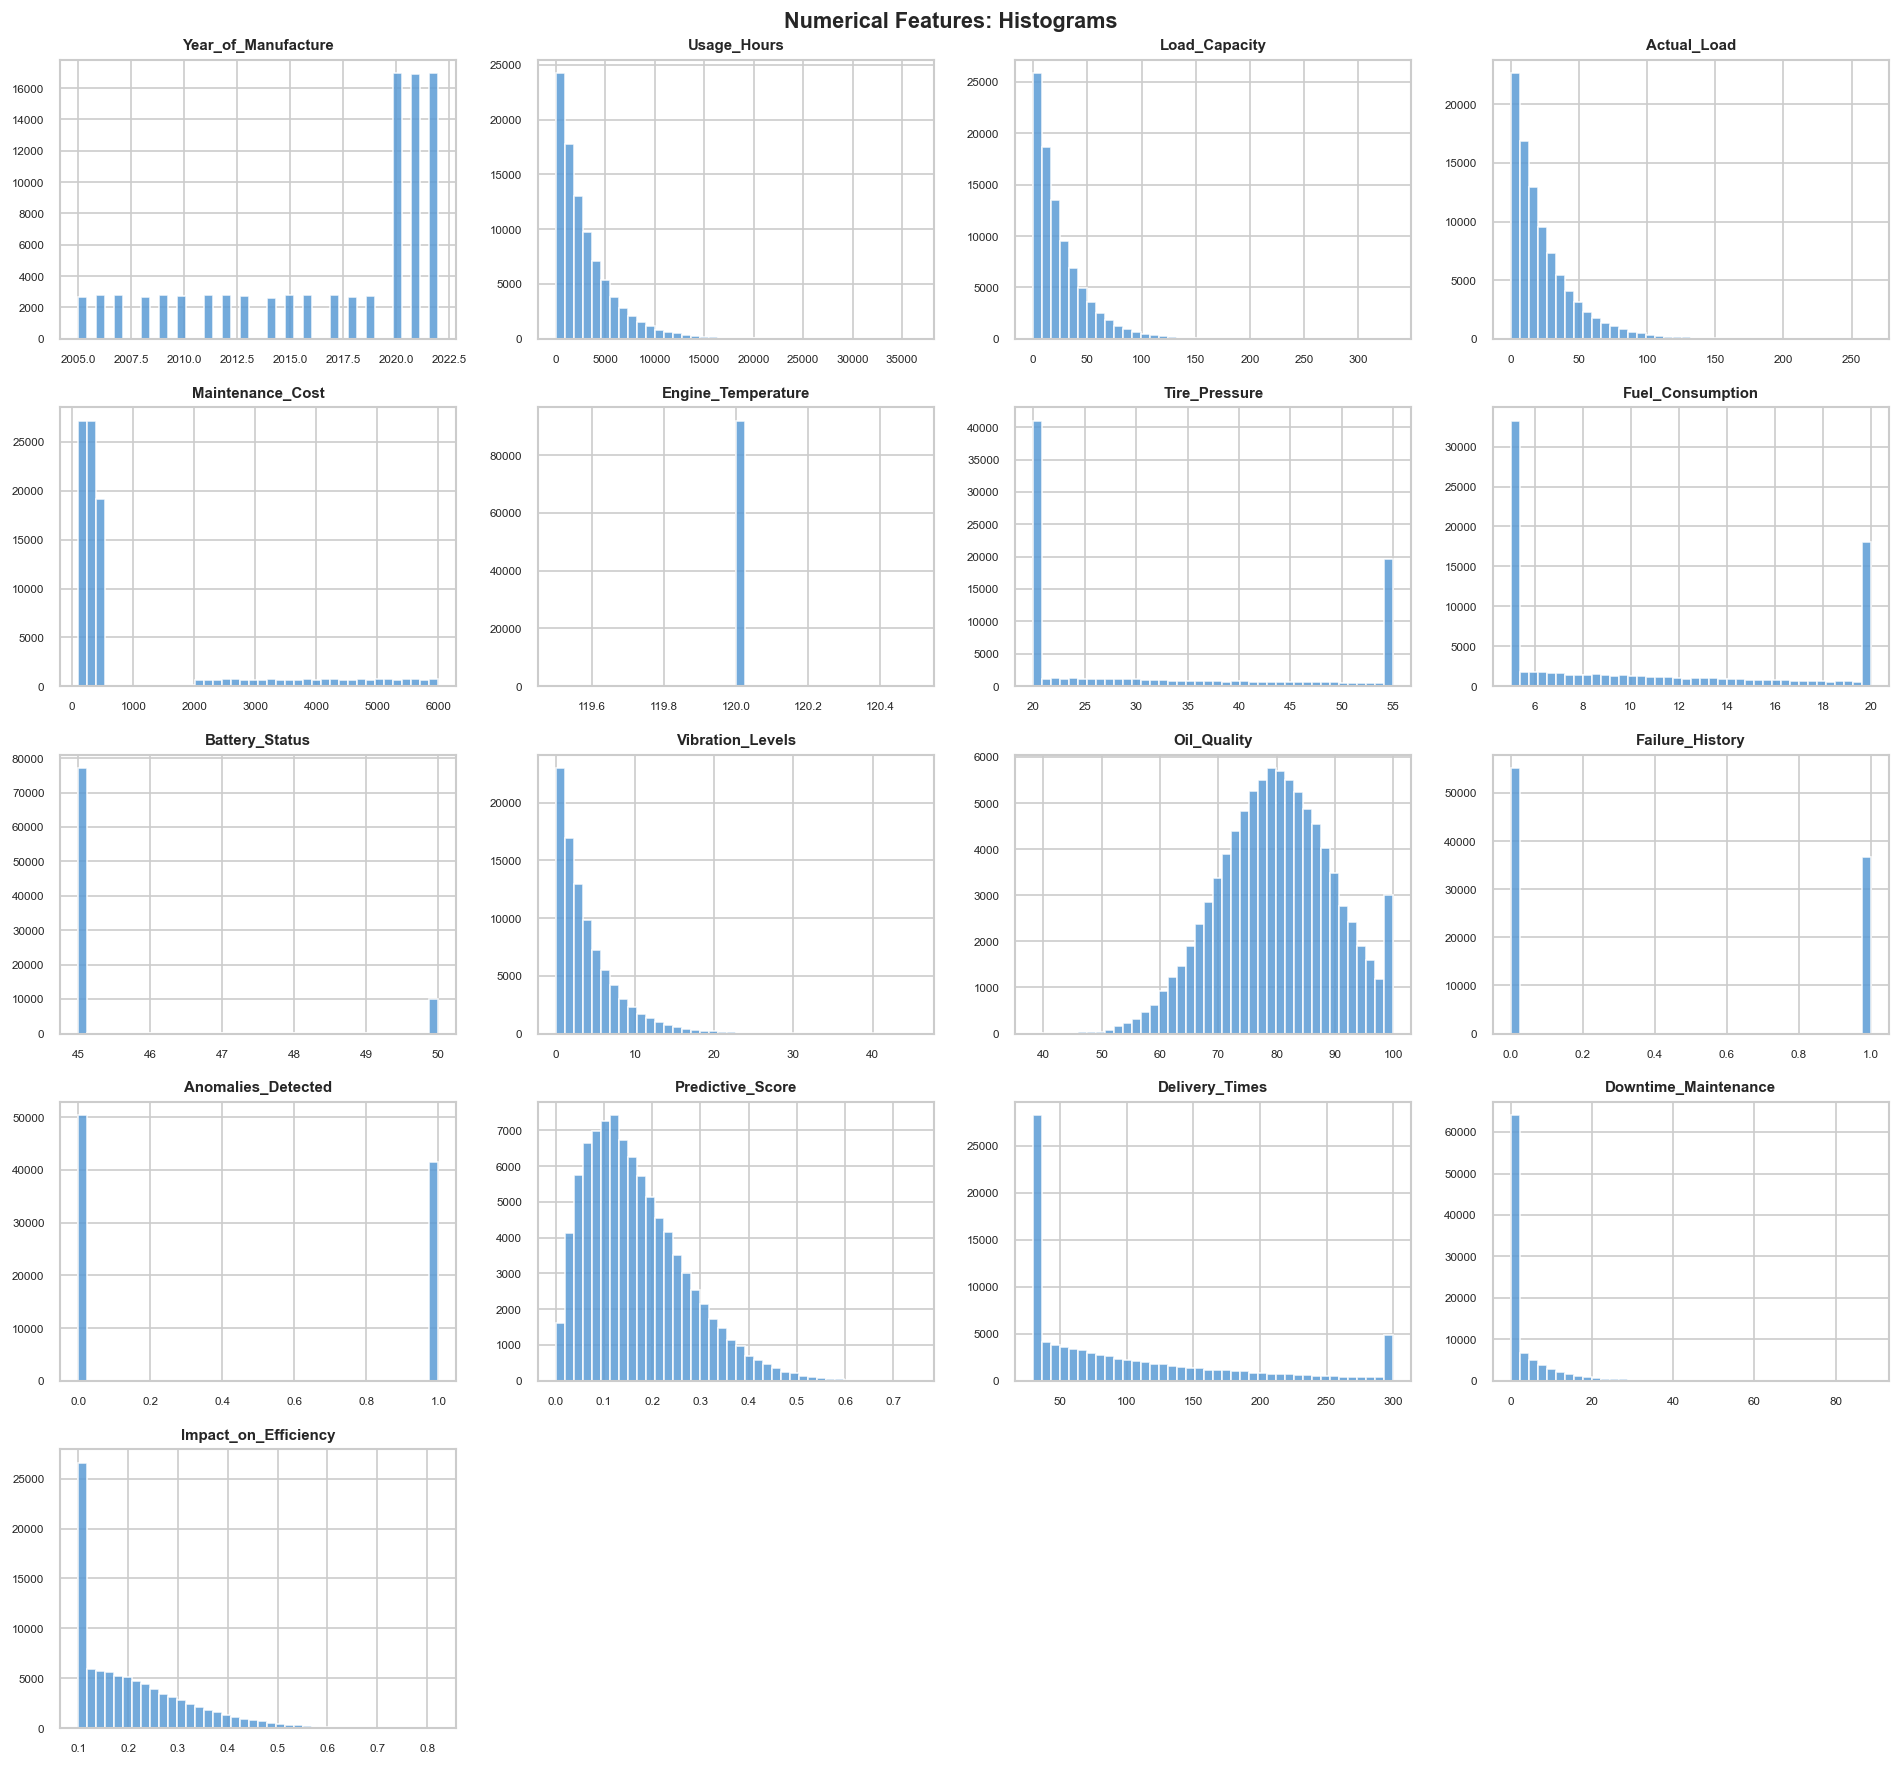

In [12]:
# Plot histograms for all numerical features (excluding ID and target).
plot_num = [c for c in num_cols if c not in ["Vehicle_ID", "Maintenance_Required"]]

n_cols = 4
n_rows = (len(plot_num) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(plot_num):
    axes[i].hist(df[col], bins=40, color="#5B9BD5", edgecolor="white", alpha=0.85)
    axes[i].set_title(col, fontsize=9, fontweight="bold")
    axes[i].tick_params(labelsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Numerical Features: Histograms", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../images/02_numerical_histograms.png", bbox_inches="tight")
plt.show()

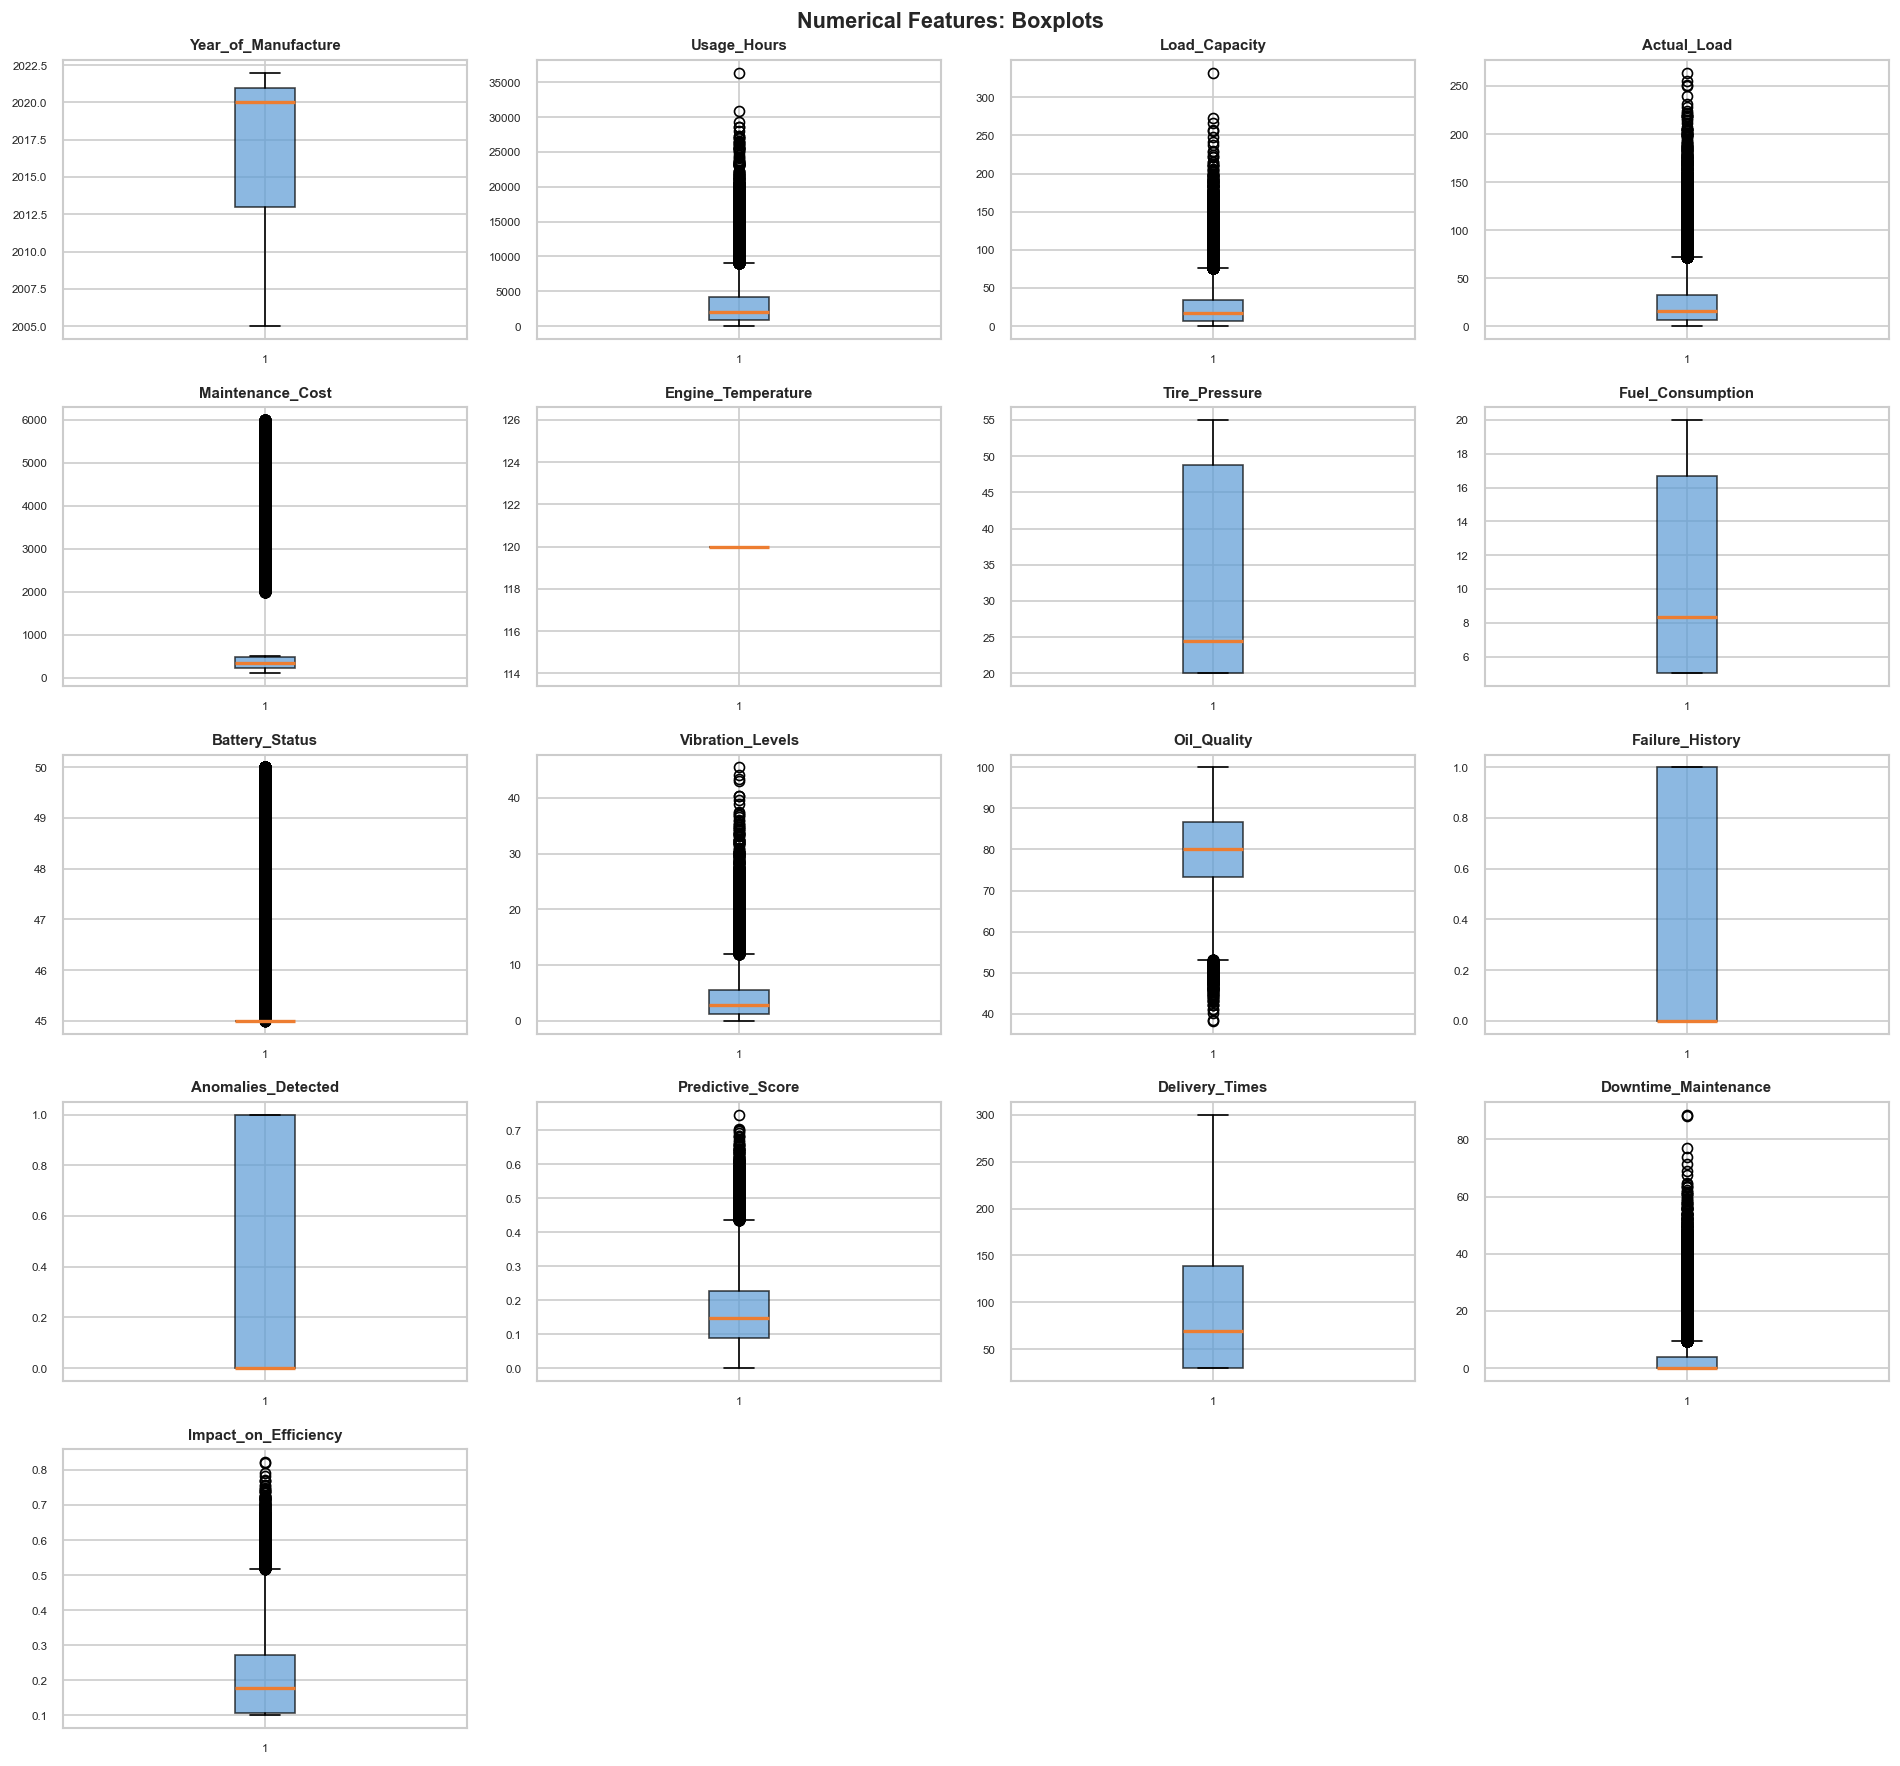

In [13]:
# Plot boxplots for all numerical features to visualize spread and detect outliers.
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(plot_num):
    axes[i].boxplot(df[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor="#5B9BD5", alpha=0.7),
                    medianprops=dict(color="#ED7D31", linewidth=2))
    axes[i].set_title(col, fontsize=9, fontweight="bold")
    axes[i].tick_params(labelsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Numerical Features: Boxplots", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../images/03_numerical_boxplots.png", bbox_inches="tight")
plt.show()

## 6. Categorical Feature Distributions

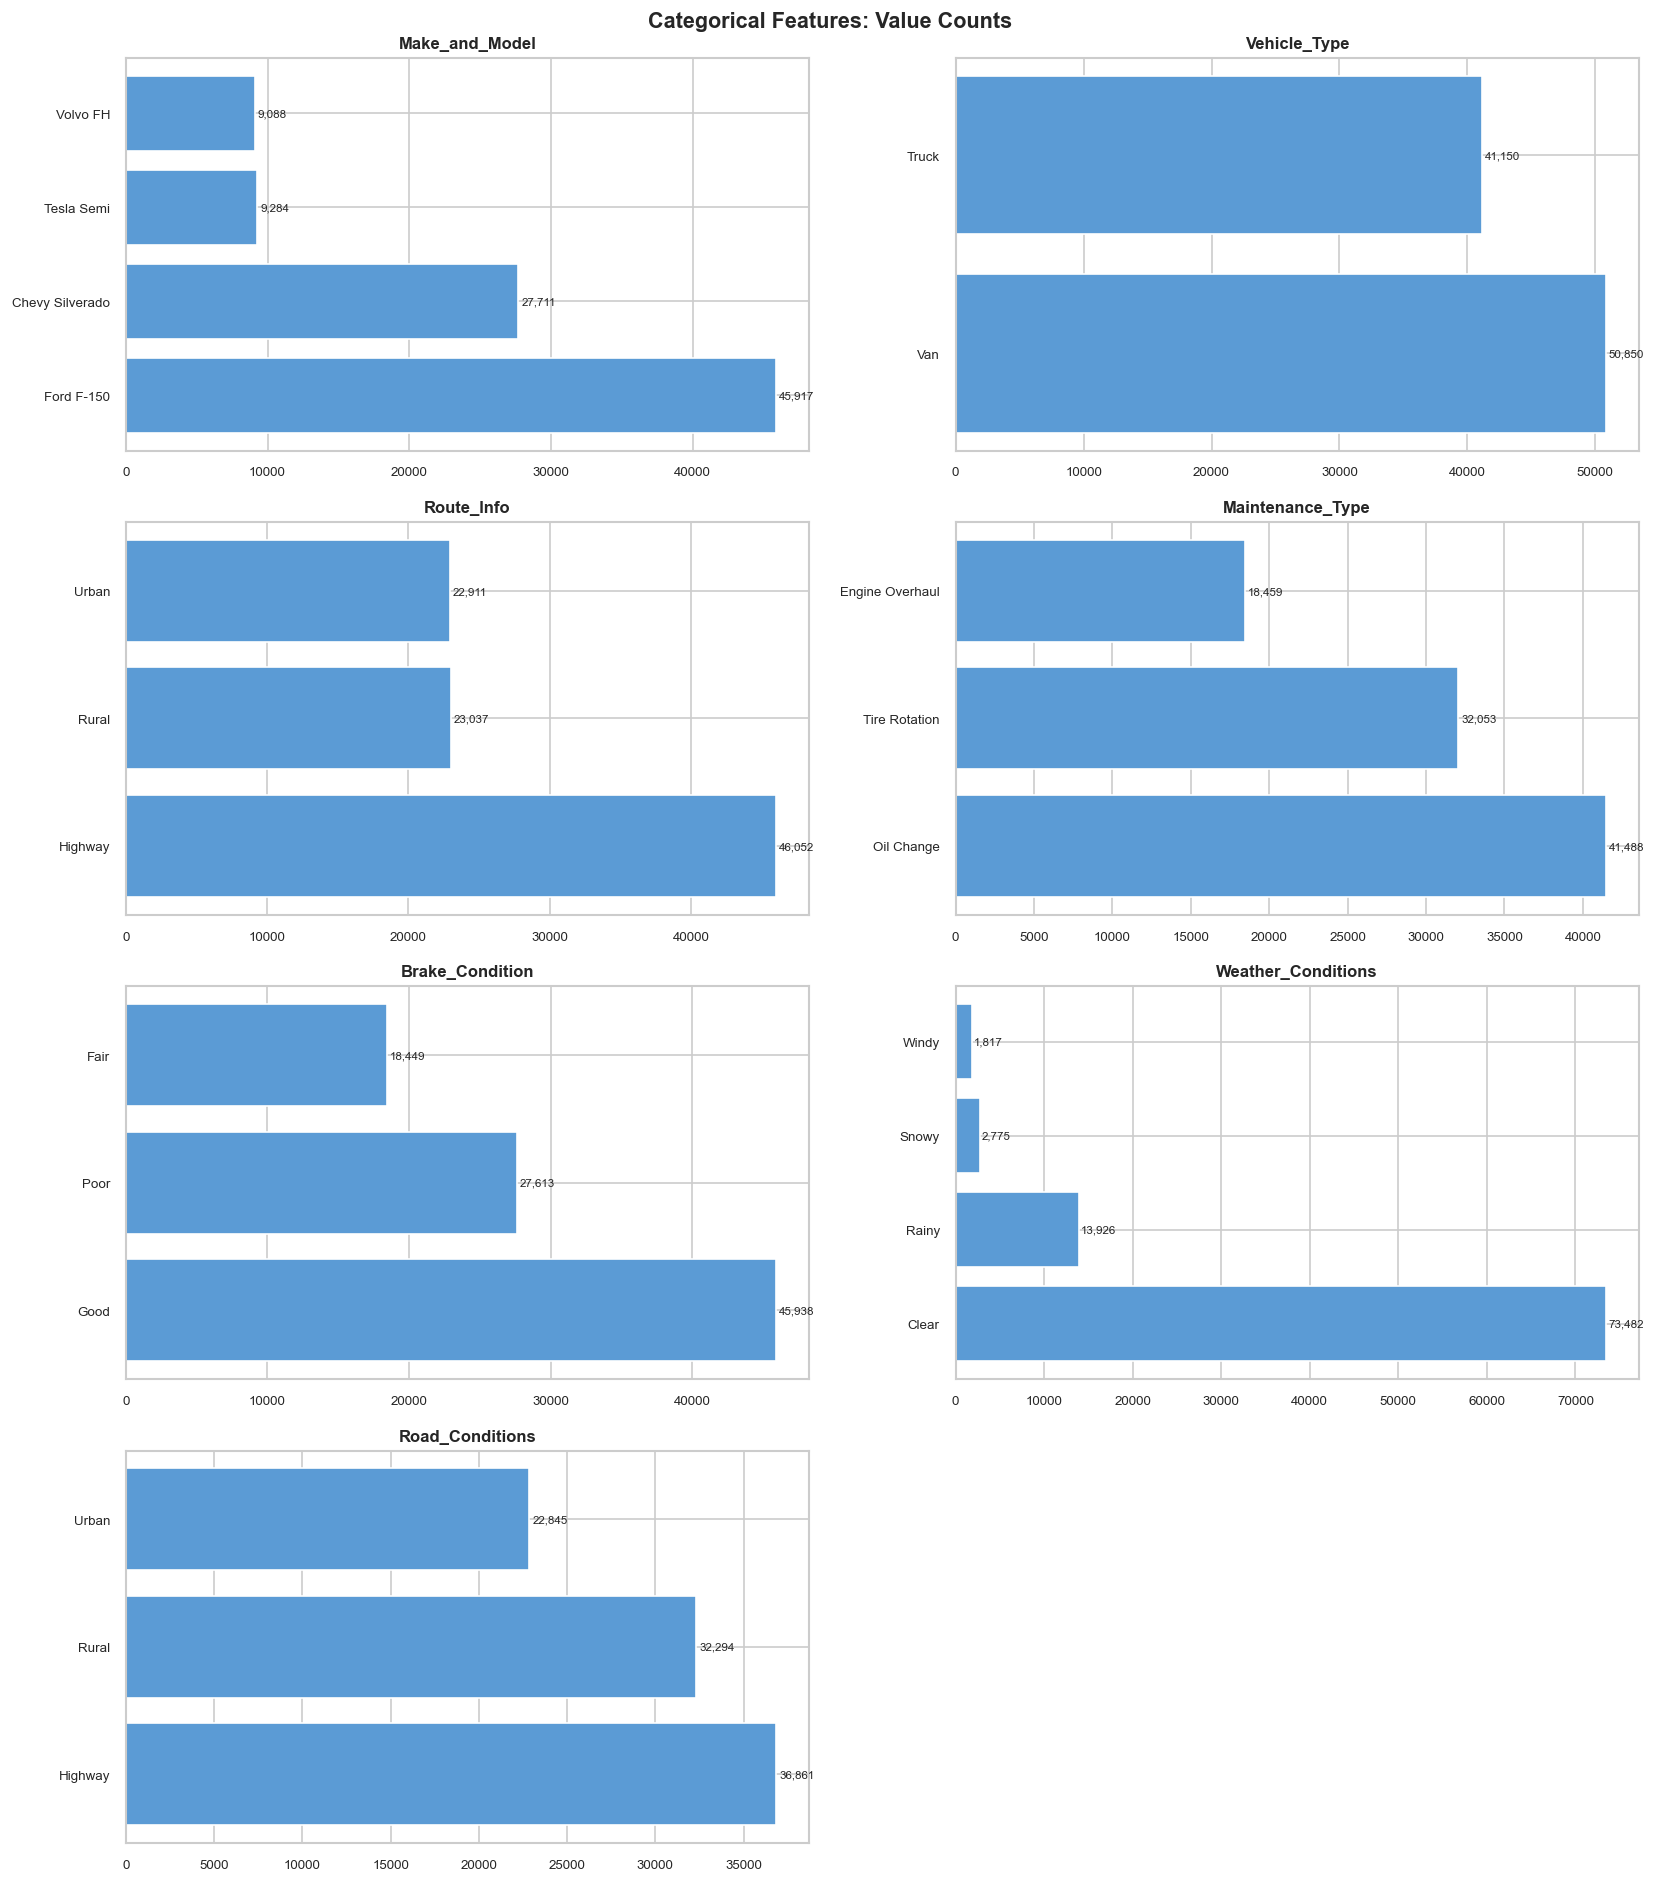

In [14]:
# Plot value counts for each categorical column to understand category balance.
plot_cat = [c for c in cat_cols if c != "Last_Maintenance_Date"]

n_cols_c = 2
n_rows_c = (len(plot_cat) + 1) // 2

fig, axes = plt.subplots(n_rows_c, n_cols_c, figsize=(14, n_rows_c * 4))
axes = axes.flatten()

for i, col in enumerate(plot_cat):
    vc = df[col].value_counts()
    bars = axes[i].barh(vc.index.astype(str), vc.values, color="#5B9BD5", edgecolor="white")
    axes[i].set_title(col, fontsize=10, fontweight="bold")
    axes[i].tick_params(labelsize=8)
    for bar, v in zip(bars, vc.values):
        axes[i].text(v + 200, bar.get_y() + bar.get_height() / 2,
                     f"{v:,}", va="center", fontsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Categorical Features: Value Counts", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../images/04_categorical_distributions.png", bbox_inches="tight")
plt.show()

## 7. Feature Relationships with Target

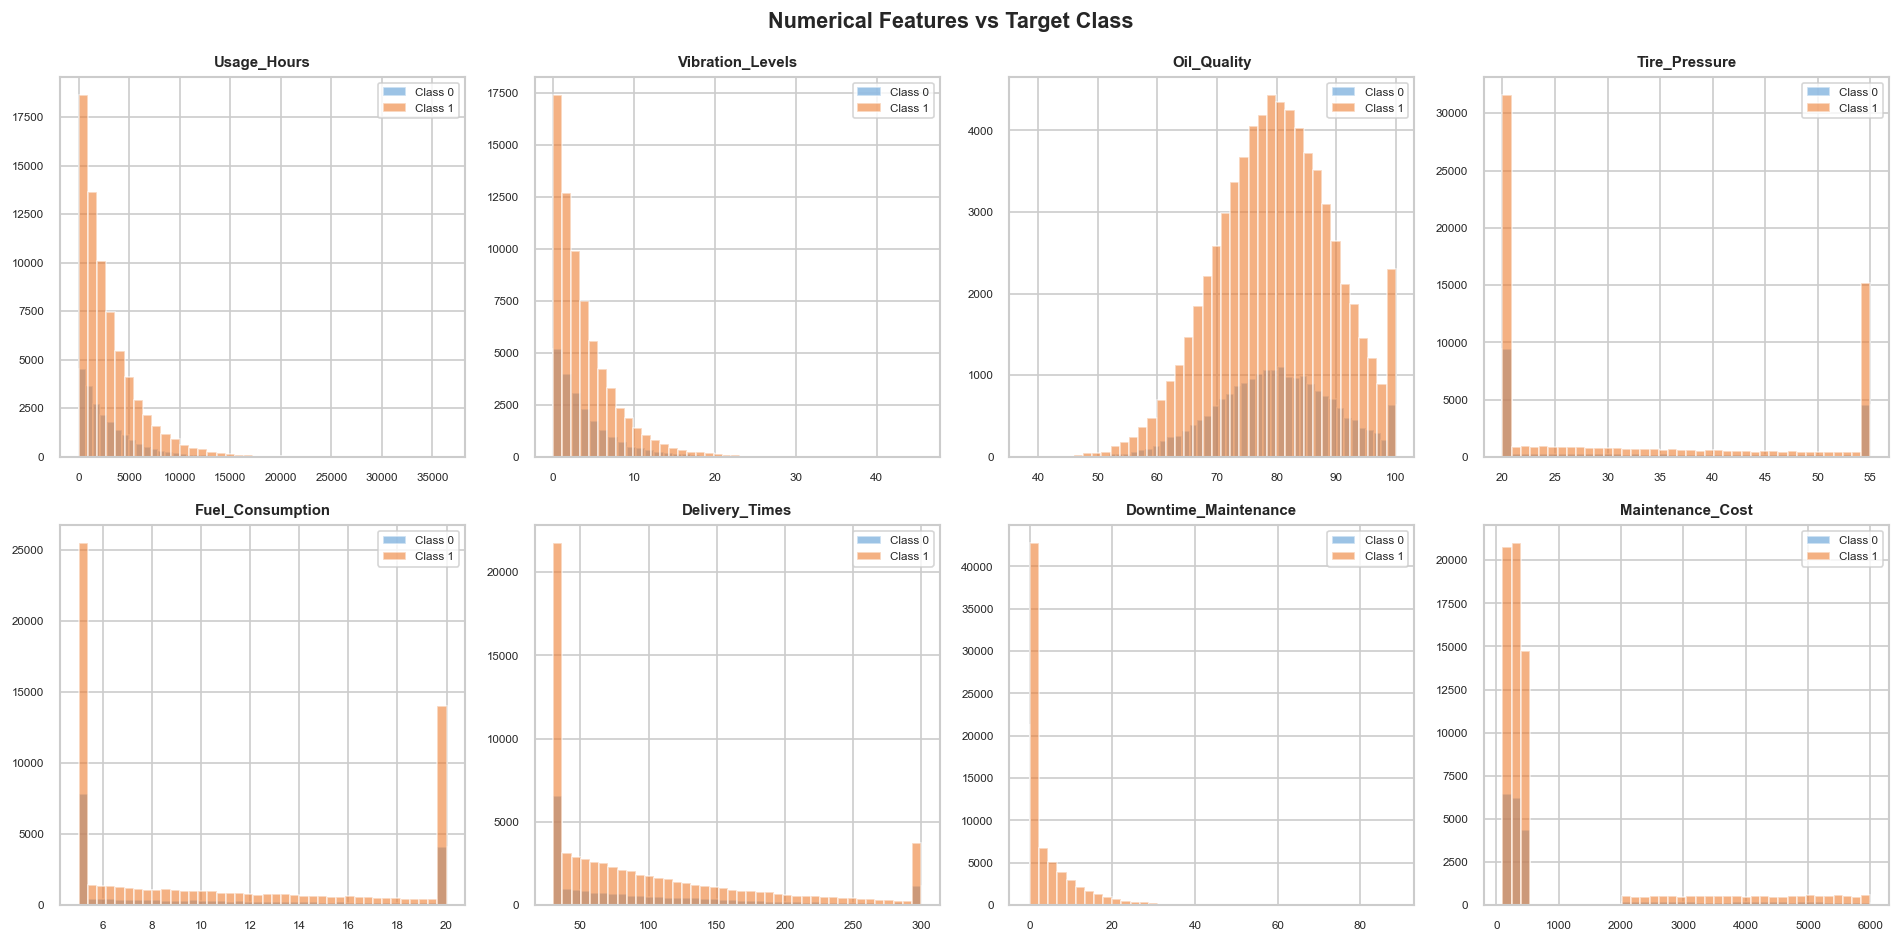

In [15]:
# Compare key numerical feature distributions between the two target classes.
target_colors = {0: "#5B9BD5", 1: "#ED7D31"}

key_num = ["Usage_Hours", "Vibration_Levels", "Oil_Quality", "Tire_Pressure",
           "Fuel_Consumption", "Delivery_Times", "Downtime_Maintenance", "Maintenance_Cost"]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(key_num):
    for cls in [0, 1]:
        axes[i].hist(
            df[df["Maintenance_Required"] == cls][col],
            bins=40, alpha=0.6, color=target_colors[cls],
            label=f"Class {cls}", edgecolor="white"
        )
    axes[i].set_title(col, fontsize=9, fontweight="bold")
    axes[i].legend(fontsize=7)
    axes[i].tick_params(labelsize=7)

plt.suptitle("Numerical Features vs Target Class", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../images/05_numerical_vs_target.png", bbox_inches="tight")
plt.show()

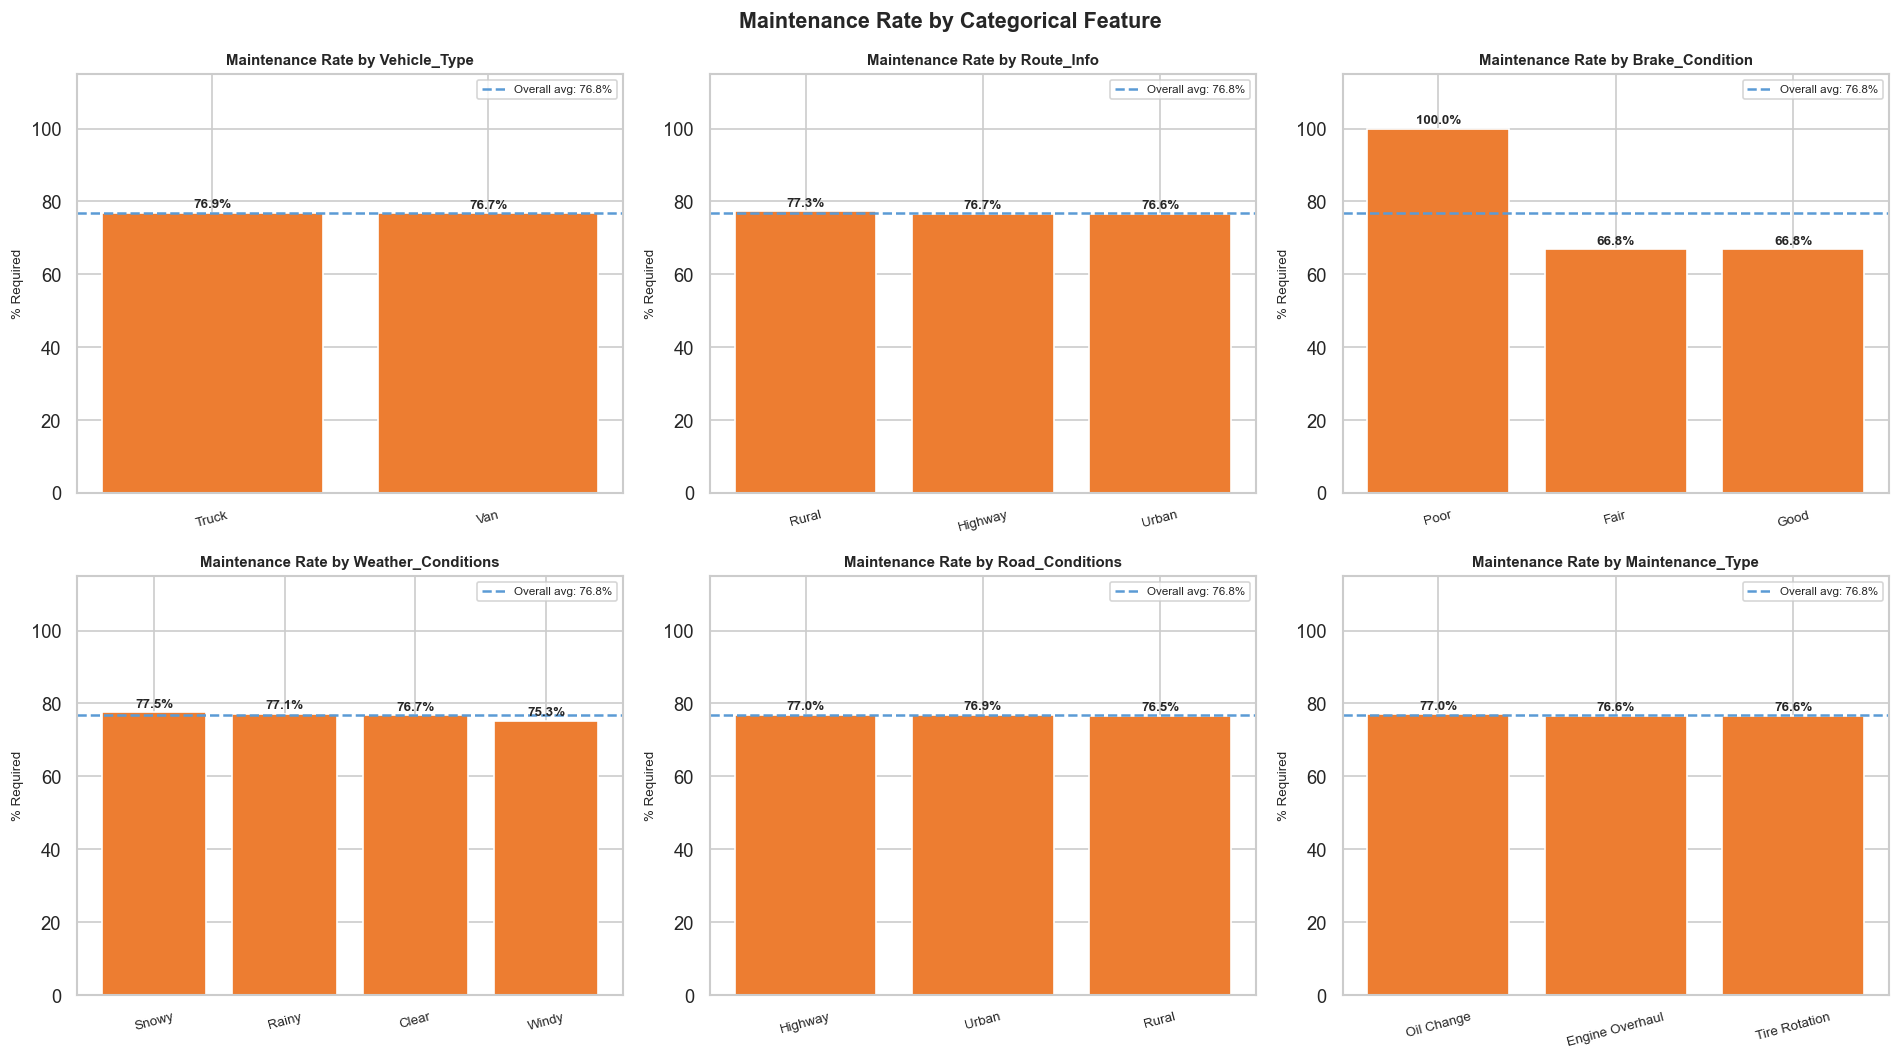

In [16]:
# Calculate maintenance rate per category to find the most influential categorical features.
cat_analysis = ["Vehicle_Type", "Route_Info", "Brake_Condition",
                "Weather_Conditions", "Road_Conditions", "Maintenance_Type"]

overall_rate = df["Maintenance_Required"].mean() * 100

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(cat_analysis):
    rate = (df.groupby(col)["Maintenance_Required"].mean() * 100).sort_values(ascending=False)
    bars = axes[i].bar(rate.index.astype(str), rate.values, color="#ED7D31", edgecolor="white")
    axes[i].axhline(overall_rate, color="#5B9BD5", linestyle="--",
                    linewidth=1.5, label=f"Overall avg: {overall_rate:.1f}%")
    axes[i].set_title(f"Maintenance Rate by {col}", fontsize=9, fontweight="bold")
    axes[i].set_ylabel("% Required", fontsize=8)
    axes[i].tick_params(axis="x", rotation=15, labelsize=8)
    axes[i].legend(fontsize=7)
    axes[i].set_ylim(0, 115)
    for bar, v in zip(bars, rate.values):
        axes[i].text(bar.get_x() + bar.get_width() / 2, v + 1.5,
                     f"{v:.1f}%", ha="center", fontsize=8, fontweight="bold")

plt.suptitle("Maintenance Rate by Categorical Feature", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../images/06_maintenance_rate_by_category.png", bbox_inches="tight")
plt.show()

## 8. Correlation Analysis

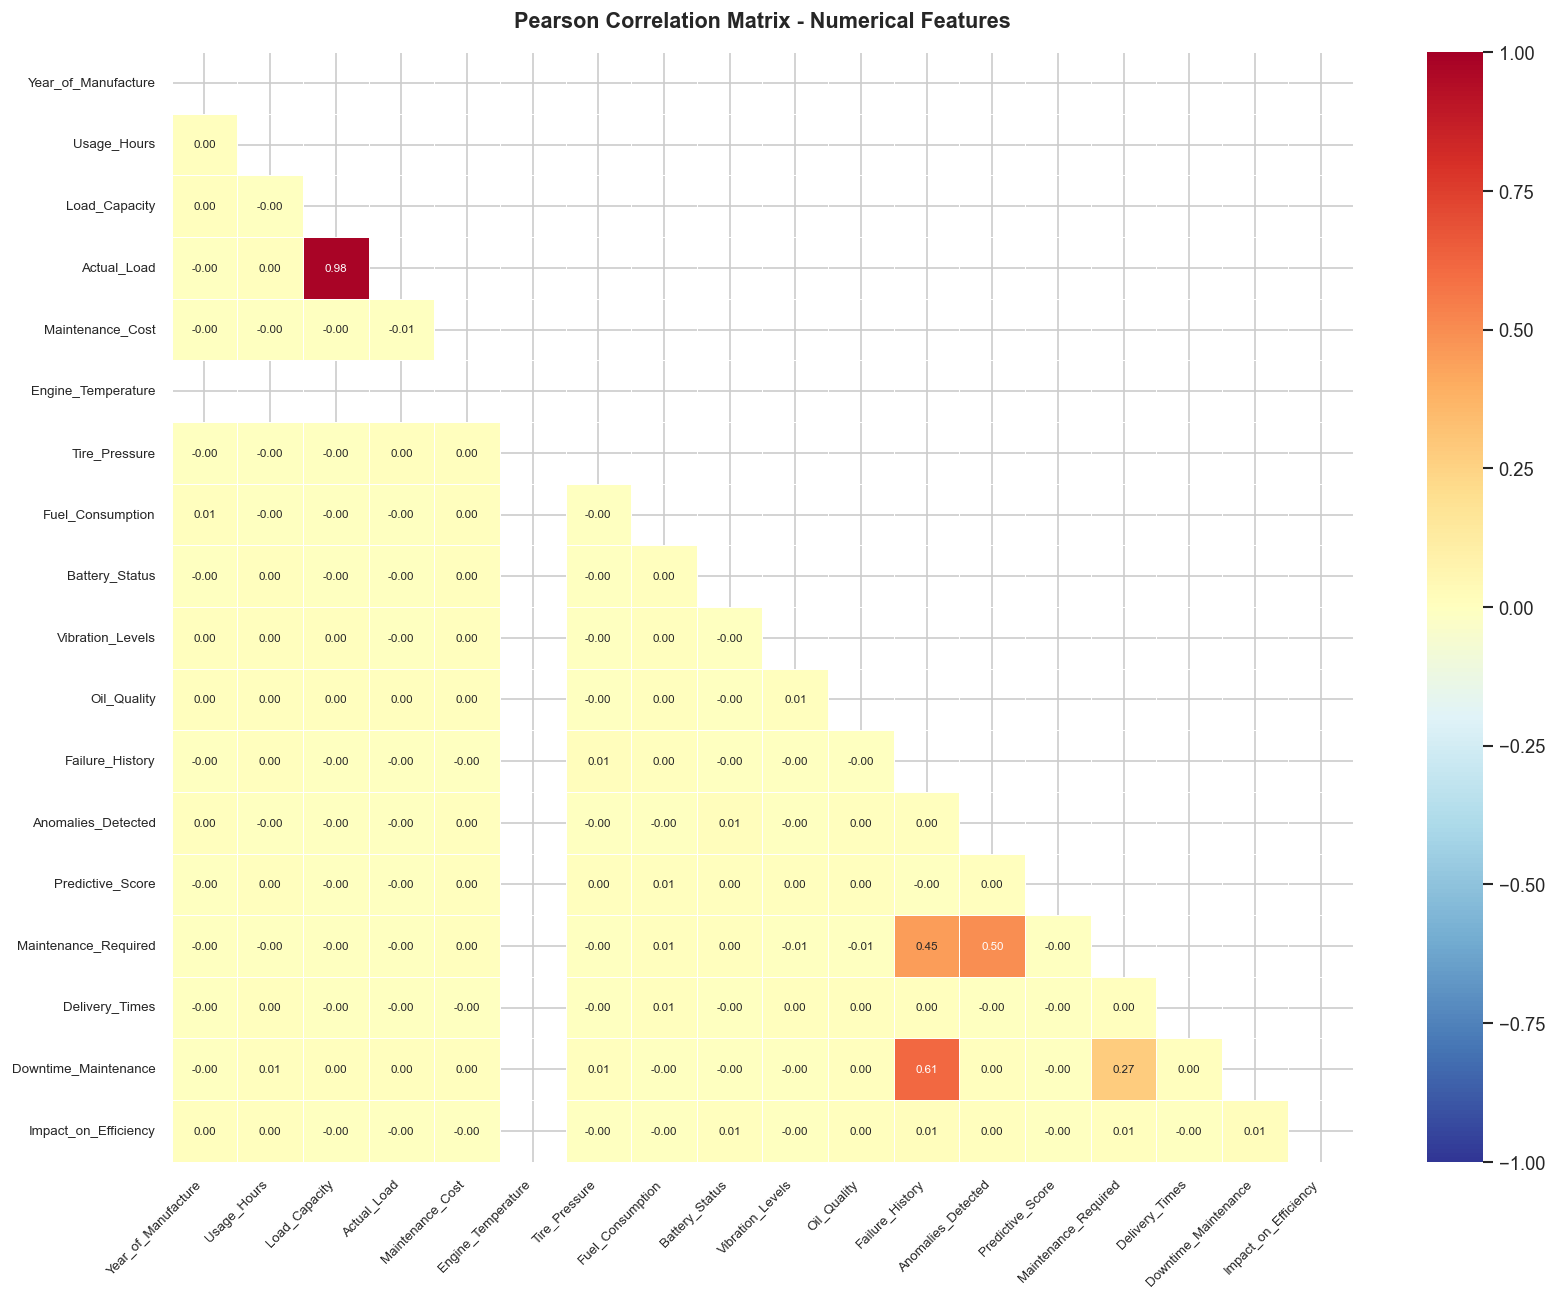

In [17]:
# Compute and visualize the Pearson correlation matrix for all numerical features.
num_corr = [c for c in num_cols if c != "Vehicle_ID"]
corr_matrix = df[num_corr].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdYlBu_r",
            center=0, linewidths=0.5, ax=ax,
            annot_kws={"size": 7}, mask=mask, vmin=-1, vmax=1)
ax.set_title("Pearson Correlation Matrix - Numerical Features",
             fontsize=13, fontweight="bold", pad=15)
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig("../images/07_correlation_matrix.png", bbox_inches="tight")
plt.show()

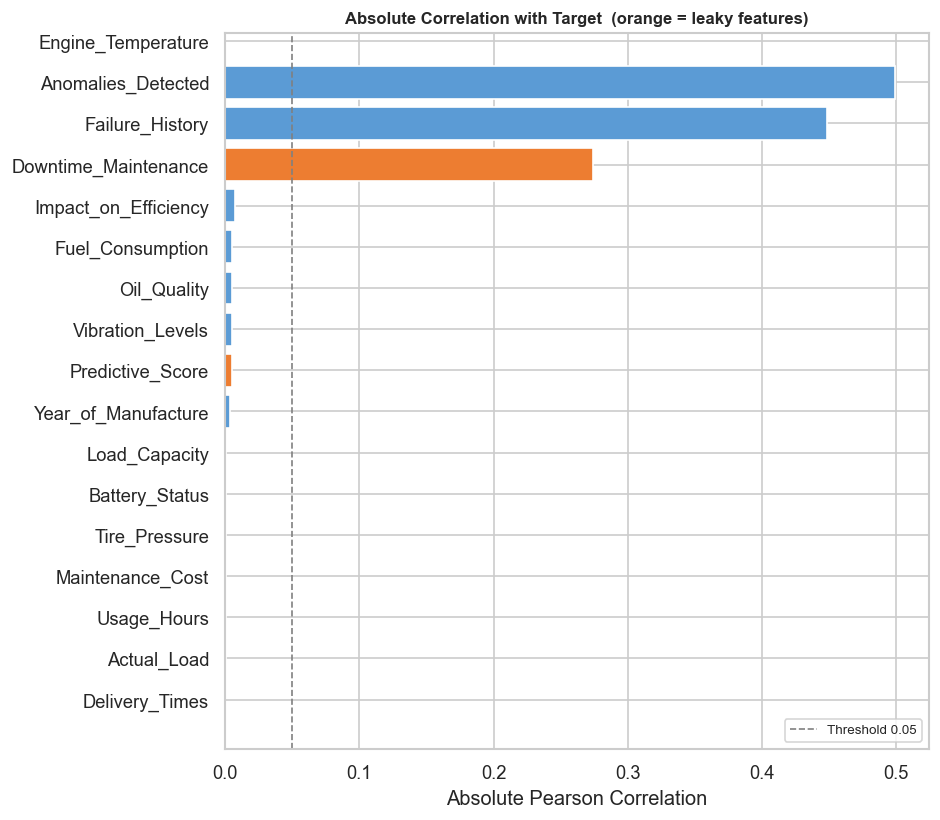


Top correlations with target:
Anomalies_Detected     0.499
Failure_History        0.448
Downtime_Maintenance   0.274
Impact_on_Efficiency   0.007
Fuel_Consumption       0.005
Oil_Quality            0.005
Vibration_Levels       0.005
Predictive_Score       0.005
Year_of_Manufacture    0.003
Load_Capacity          0.001
Battery_Status         0.001
Tire_Pressure          0.001
Maintenance_Cost       0.001
Usage_Hours            0.001
Actual_Load            0.000
Delivery_Times         0.000
Engine_Temperature       NaN


In [18]:
# Rank all numerical features by absolute correlation with the target variable.
corr_target = (
    df[num_corr].corr()["Maintenance_Required"]
    .drop("Maintenance_Required")
    .abs()
    .sort_values(ascending=True)
)

leaky = ["Predictive_Score", "Downtime_Maintenance", "Maintenance_Cost"]
bar_colors = ["#ED7D31" if c in leaky else "#5B9BD5" for c in corr_target.index]

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(corr_target.index, corr_target.values, color=bar_colors)
ax.axvline(0.05, color="grey", linestyle="--", linewidth=1, label="Threshold 0.05")
ax.set_title("Absolute Correlation with Target  (orange = leaky features)",
             fontsize=10, fontweight="bold")
ax.set_xlabel("Absolute Pearson Correlation")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("../images/08_correlation_with_target.png", bbox_inches="tight")
plt.show()

print("\nTop correlations with target:")
print(corr_target.sort_values(ascending=False).round(4).to_string())

## 9. Outlier Detection (IQR Method)

In [19]:
# Identify outliers in each numerical feature using the interquartile range method.
cols_out = [c for c in num_cols if c not in ["Vehicle_ID", "Maintenance_Required"]]

rows = []
for col in cols_out:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    lo, hi = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_out = int(((df[col] < lo) | (df[col] > hi)).sum())
    rows.append({"Feature": col, "Q1": round(Q1, 2), "Q3": round(Q3, 2),
                 "Lower_Fence": round(lo, 2), "Upper_Fence": round(hi, 2),
                 "Outlier_Count": n_out,
                 "Outlier_Pct": round(n_out / len(df) * 100, 2)})

outlier_df = pd.DataFrame(rows).sort_values("Outlier_Count", ascending=False)
print(outlier_df.to_string(index=False))

             Feature       Q1       Q3  Lower_Fence  Upper_Fence  Outlier_Count  Outlier_Pct
    Maintenance_Cost  225.210  474.930     -149.350      849.490          18459       20.060
      Battery_Status   45.000   45.000       45.000       45.000          14945       16.240
Downtime_Maintenance    0.000    3.780       -5.660        9.440          11285       12.270
         Actual_Load    6.730   32.680      -32.210       71.620           4720        5.130
         Usage_Hours  856.000 4146.000    -4079.000     9081.000           4496        4.890
    Vibration_Levels    1.140    5.500       -5.410       12.040           4485        4.880
       Load_Capacity    7.230   34.750      -34.040       76.020           4456        4.840
    Predictive_Score    0.090    0.230       -0.120        0.440           1615        1.760
Impact_on_Efficiency    0.110    0.270       -0.140        0.520           1412        1.530
         Oil_Quality   73.320   86.750       53.170      106.900      

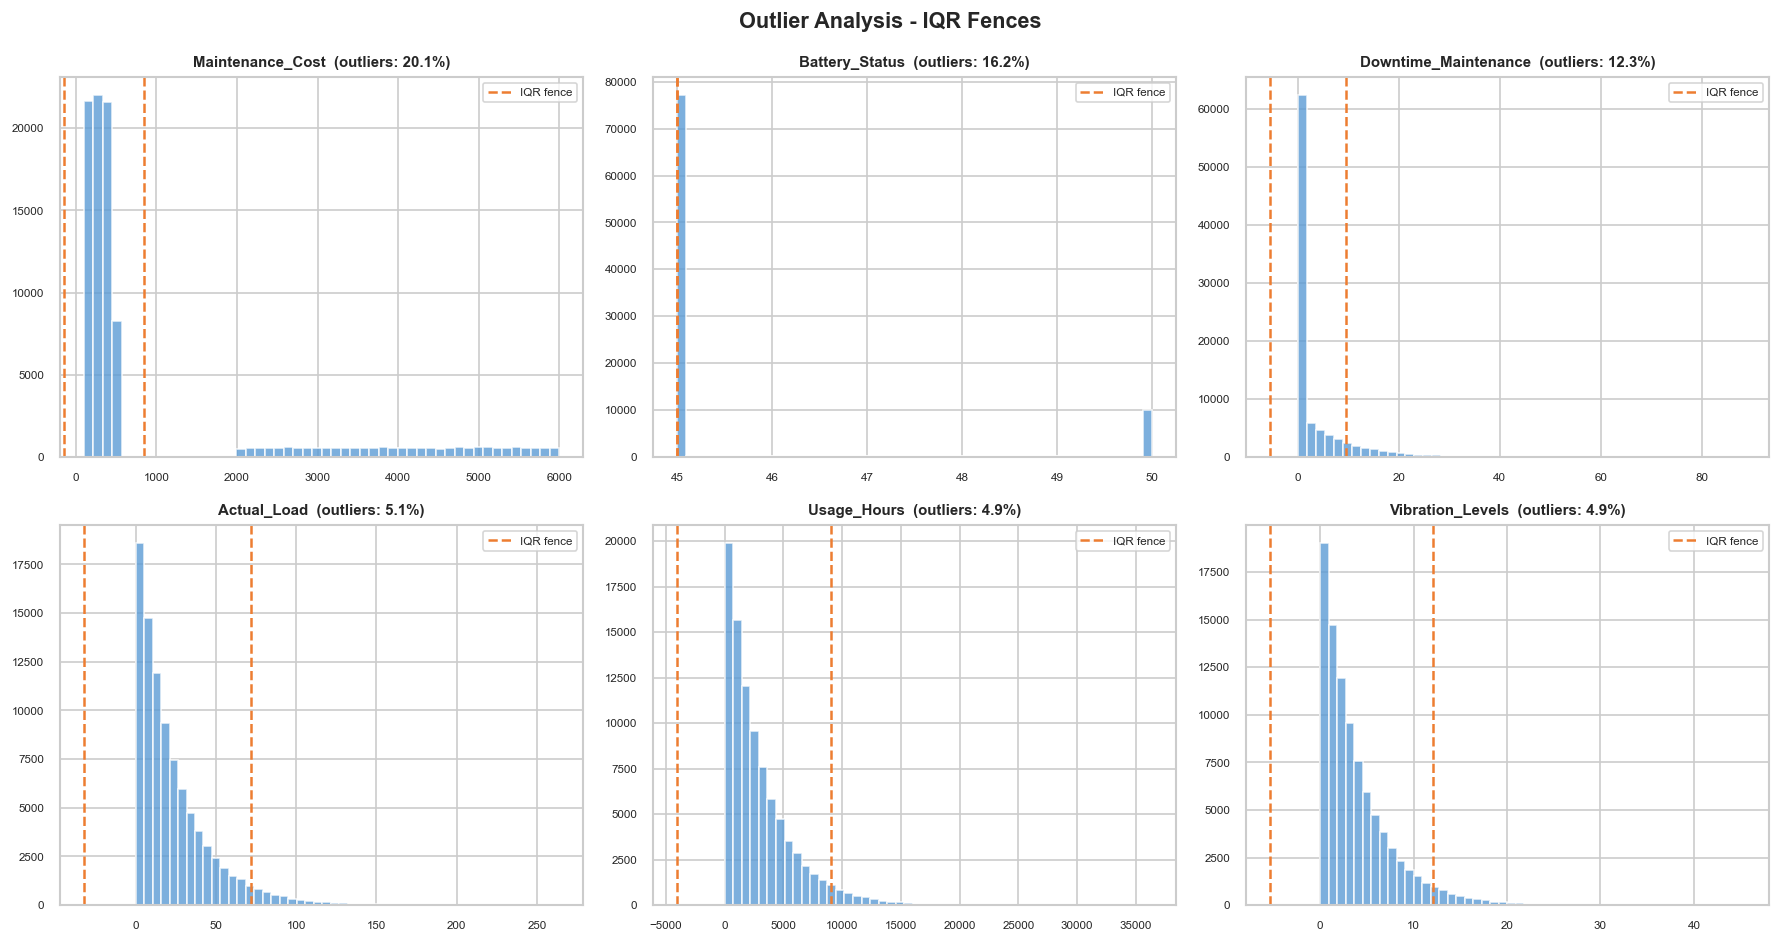

In [20]:
# Visualize top outlier-heavy features with their IQR fences.
top_out_cols = outlier_df[outlier_df["Outlier_Count"] > 0]["Feature"].head(6).tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(top_out_cols):
    row = outlier_df[outlier_df["Feature"] == col].iloc[0]
    axes[i].hist(df[col], bins=50, color="#5B9BD5", edgecolor="white", alpha=0.8)
    axes[i].axvline(row["Lower_Fence"], color="#ED7D31", linestyle="--",
                    linewidth=1.5, label="IQR fence")
    axes[i].axvline(row["Upper_Fence"], color="#ED7D31", linestyle="--", linewidth=1.5)
    axes[i].set_title(f"{col}  (outliers: {row['Outlier_Pct']:.1f}%)",
                      fontsize=9, fontweight="bold")
    axes[i].legend(fontsize=7)
    axes[i].tick_params(labelsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Outlier Analysis - IQR Fences", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../images/09_outlier_analysis.png", bbox_inches="tight")
plt.show()

## 10. Data Leakage Investigation

**What is data leakage?**
Leakage happens when a feature contains information that would not be available at
prediction time. Using such features produces artificially high training performance
but fails in production.

| Column | Reason |
|--------|--------|
| `Predictive_Score` | Pre-computed risk score, directly derived from the target |
| `Maintenance_Cost` | Cost is only known after maintenance is performed |
| `Maintenance_Type` | Type is only known after maintenance is performed |
| `Downtime_Maintenance` | Actual downtime is recorded only after the event |

These columns must be excluded from model features.

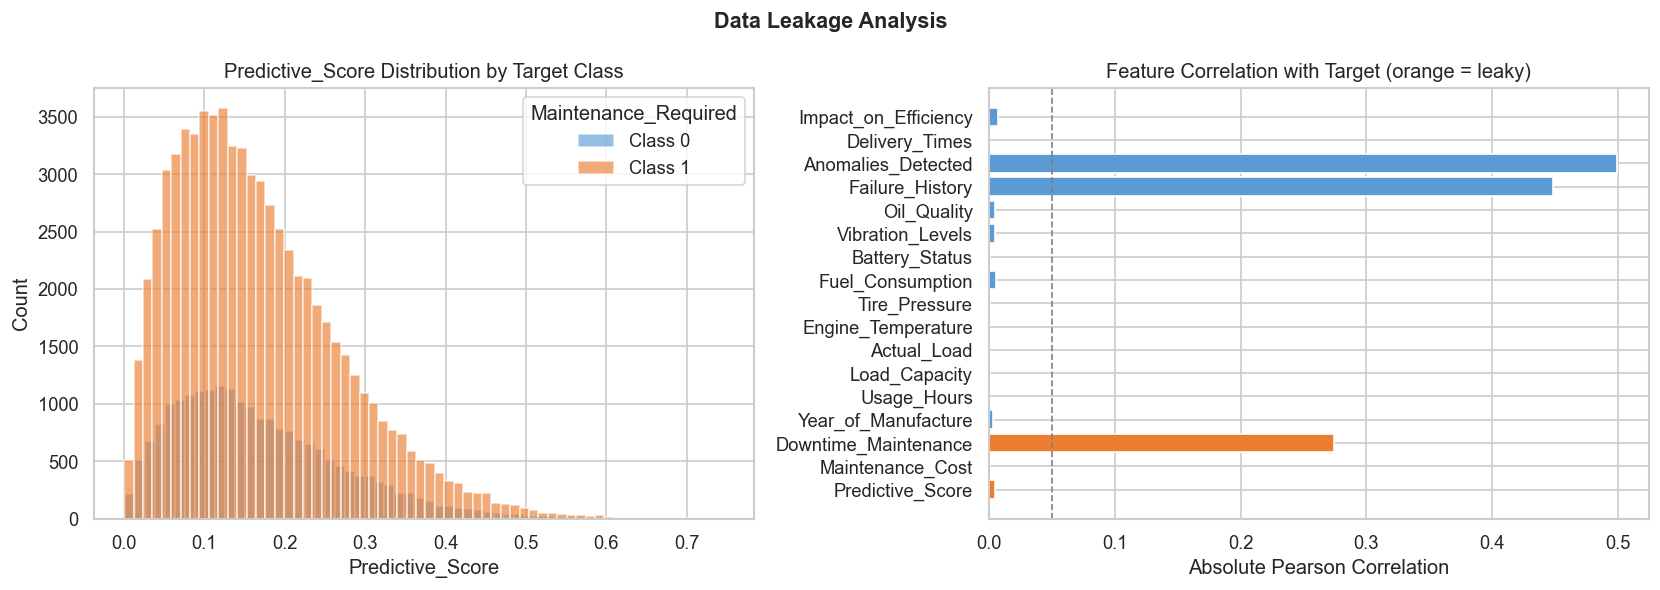

Predictive_Score           corr = -0.0050
Maintenance_Cost           corr = 0.0006
Downtime_Maintenance       corr = 0.2744


In [21]:
# Visualize Predictive_Score by target class to confirm it leaks the label.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for cls in [0, 1]:
    axes[0].hist(
        df[df["Maintenance_Required"] == cls]["Predictive_Score"],
        bins=60, alpha=0.65, color=target_colors[cls],
        label=f"Class {cls}", edgecolor="white"
    )
axes[0].set_title("Predictive_Score Distribution by Target Class")
axes[0].set_xlabel("Predictive_Score")
axes[0].set_ylabel("Count")
axes[0].legend(title="Maintenance_Required")

leaky_cols = ["Predictive_Score", "Maintenance_Cost", "Downtime_Maintenance"]
clean_cols  = [c for c in num_corr
               if c not in leaky_cols + ["Maintenance_Required"]]

for col in leaky_cols:
    cv = abs(df[col].corr(df["Maintenance_Required"]))
    axes[1].barh(col, cv, color="#ED7D31")
for col in clean_cols:
    cv = abs(df[col].corr(df["Maintenance_Required"]))
    axes[1].barh(col, cv, color="#5B9BD5")

axes[1].axvline(0.05, color="grey", linestyle="--", linewidth=1)
axes[1].set_title("Feature Correlation with Target (orange = leaky)")
axes[1].set_xlabel("Absolute Pearson Correlation")

plt.suptitle("Data Leakage Analysis", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../images/10_leakage_analysis.png", bbox_inches="tight")
plt.show()

for col in leaky_cols:
    print(f"{col:25s}  corr = {df[col].corr(df['Maintenance_Required']):.4f}")

## 11. Feature Engineering Opportunities

In [22]:
# Create derived features that better represent the physical condition of each vehicle.
df_fe = df.copy()

df_fe["vehicle_age"]            = 2024 - df_fe["Year_of_Manufacture"]
df_fe["overload_ratio"]         = df_fe["Actual_Load"] / df_fe["Load_Capacity"]
df_fe["is_overloaded"]          = (df_fe["Actual_Load"] > df_fe["Load_Capacity"]).astype(int)
df_fe["last_maint_dt"]          = pd.to_datetime(df_fe["Last_Maintenance_Date"])
df_fe["days_since_maintenance"] = (pd.Timestamp("2024-12-31") - df_fe["last_maint_dt"]).dt.days

new_feats = ["vehicle_age", "overload_ratio", "is_overloaded", "days_since_maintenance"]
corr_new  = (df_fe[new_feats + ["Maintenance_Required"]]
             .corr()["Maintenance_Required"]
             .drop("Maintenance_Required")
             .sort_values(ascending=False))

print("Correlation of engineered features with target:")
print(corr_new.round(4).to_string())

Correlation of engineered features with target:
vehicle_age               0.003
overload_ratio            0.003
is_overloaded             0.002
days_since_maintenance   -0.006


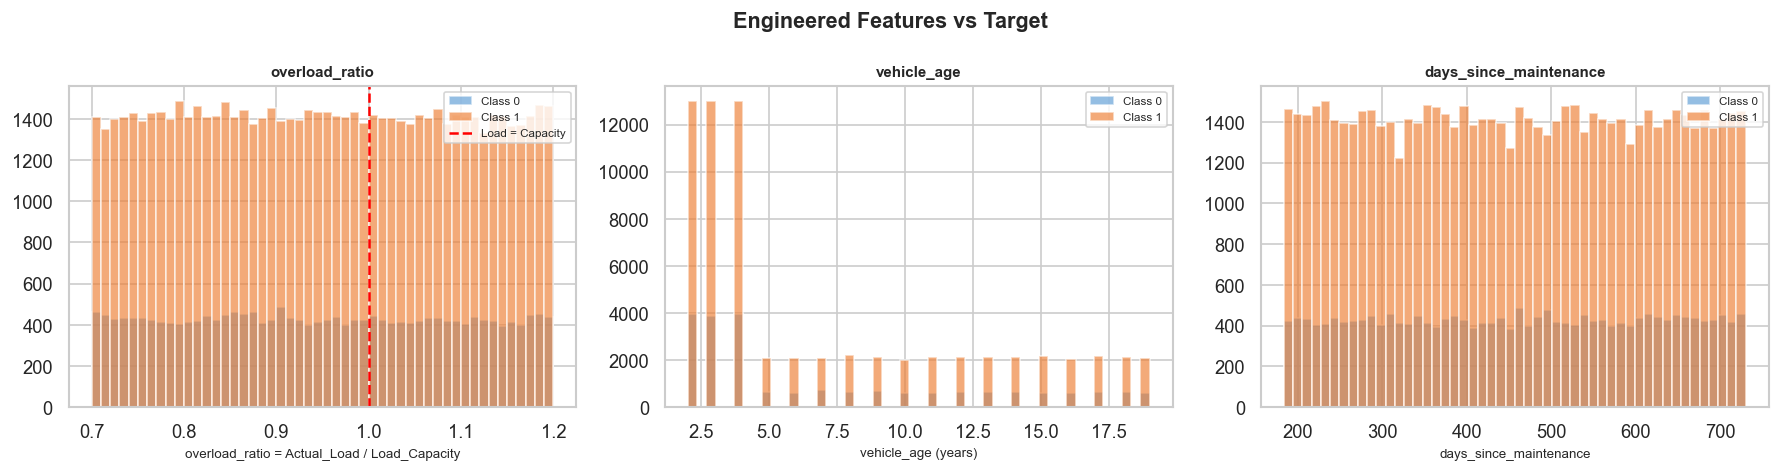

In [23]:
# Visualize the three most useful engineered features split by maintenance requirement.
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

fe_plot = [
    ("overload_ratio",         "overload_ratio = Actual_Load / Load_Capacity"),
    ("vehicle_age",            "vehicle_age (years)"),
    ("days_since_maintenance", "days_since_maintenance"),
]

for ax, (col, xlabel) in zip(axes, fe_plot):
    for cls in [0, 1]:
        ax.hist(df_fe[df_fe["Maintenance_Required"] == cls][col],
                bins=50, alpha=0.65, color=target_colors[cls],
                label=f"Class {cls}", edgecolor="white")
    if col == "overload_ratio":
        ax.axvline(1.0, color="red", linestyle="--", linewidth=1.5, label="Load = Capacity")
    ax.set_title(col, fontsize=9, fontweight="bold")
    ax.set_xlabel(xlabel, fontsize=8)
    ax.legend(fontsize=7)

plt.suptitle("Engineered Features vs Target", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../images/11_engineered_features.png", bbox_inches="tight")
plt.show()

## 12. Key Findings Summary

### Data Quality
- 92 000 records, 27 columns, zero missing values, zero duplicates.
- `Engine_Temperature` is constant (120.0) - will be dropped.
- `Battery_Status` has only 2 distinct values - will be reviewed before modeling.
- The dataset is synthetically generated, which will be stated in the README.

### Target Variable
- Class imbalance: 77 % positive (maintenance required) vs 23 % negative.
- Use F1-score, ROC-AUC, and Precision-Recall for evaluation (not accuracy).

### Data Leakage
- `Predictive_Score` correlates with the target and is a pre-computed score.
- `Maintenance_Cost`, `Maintenance_Type`, and `Downtime_Maintenance` are post-event.
- All four columns will be excluded from model features.

### Most Informative Features (clean, no leakage)
- `Vibration_Levels`, `Failure_History`, `Anomalies_Detected`, `Tire_Pressure`
- `Brake_Condition`, `Oil_Quality`, `Usage_Hours`
- Engineered: `overload_ratio`, `vehicle_age`, `days_since_maintenance`

### Next Steps
- **02_SQL_Analysis.ipynb** - SQL analysis on the normalized reference tables.
- **03_Feature_Engineering.ipynb** - full preprocessing pipeline.
- **04_Classification.ipynb** - binary classification models.